In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns
import plotly.express as px

#Dataset overview
## **1.** **Let's look at our dataset and what data columns are present there to be able understand amount of columns and rows with information about datatypes. Also, we need to check if there are missing values in there to avoid future issue during manipulation with dataframe**


*Number:* A unique identifier for each trip (Trip ID).  
*Start Date*: The date and time when the trip began.  
*Start Station Number*: The identifier for the starting station.  
*Start Station*: The name of the starting station.  
*End Date*: The date and time when the trip ended.  
*End Station Number*: The identifier for the ending station.  
*End Station*: The name of the ending station.  
*Bike Number*: A unique identifier for the bicycle used.  
*Bike Model*: The model of the bicycle used.  
*Total Duration:* The total time duration of the trip (in a human-readable format).  
*Total Duration (ms)*: The total time duration of the trip in milliseconds.






---



In [81]:
#Mount dataset from Google Drive
df_initial = pd.read_csv('/content/drive/MyDrive/Course/Data/LondonBikeJourneyAug2023.csv')


In [82]:
#Display the first 10 rows:
df_initial.head(10)

,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms)
0,132825189,8/1/2023 0:00,1190,"Kennington Lane Rail Bridge, Vauxhall",8/1/2023 0:17,1059,"Albert Embankment, Vauxhall",23715,CLASSIC,16m 46s,1006663
1,132825190,8/1/2023 0:00,1190,"Kennington Lane Rail Bridge, Vauxhall",8/1/2023 0:17,1059,"Albert Embankment, Vauxhall",41267,CLASSIC,16m 47s,1007128
2,132825191,8/1/2023 0:00,983,"Euston Road, Euston",8/1/2023 0:11,3500,"Baldwin Street, St. Luke's",53180,CLASSIC,11m 6s,666395
3,132825192,8/1/2023 0:01,3479,"Old Brompton Road, South Kensington",8/1/2023 0:12,1140,"Grosvenor Road, Pimlico",53431,CLASSIC,11m 53s,713059
4,132825193,8/1/2023 0:01,1219,"Lower Marsh, Waterloo",8/1/2023 0:17,200056,"Vauxhall Walk, Vauxhall",54758,CLASSIC,16m 3s,963786
5,132825194,8/1/2023 0:01,1219,"Lower Marsh, Waterloo",8/1/2023 0:08,1205,"Black Prince Road, Vauxhall",52921,CLASSIC,7m 45s,465422
6,132825195,8/1/2023 0:01,200120,"Grant Road East, Clapham Junction",8/1/2023 0:04,200126,"Usk Road, Clapham Junction",59224,CLASSIC,3m 26s,206583
7,132825196,8/1/2023 0:01,200155,"Gascoyne Road, Victoria Park",8/1/2023 1:04,3469,"Cadogan Place, Knightsbridge",61178,PBSC_EBIKE,1h 2m 58s,3778515
8,132825197,8/1/2023 0:01,300202,"Kings Gate House, Westminster",8/1/2023 0:18,1210,"Nevern Place, Earl's Court",51757,CLASSIC,17m 5s,1025908
9,132825198,8/1/2023 0:01,1154,"Kennington Road , Vauxhall",8/1/2023 0:09,1093,"Kennington Cross, Kennington",53424,CLASSIC,7m 16s,436692


In [83]:
# dataset shape:
df_initial.shape
print(f'The dataset has {df_initial.shape[0]} rows and {df_initial.shape[1]} columns')

The dataset has 776527 rows and 11 columns


In [84]:
# dataset column datatypes and cells with Null info:
df_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776527 entries, 0 to 776526
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Number                776527 non-null  int64 
 1   Start date            776527 non-null  object
 2   Start station number  776527 non-null  int64 
 3   Start station         776527 non-null  object
 4   End date              776527 non-null  object
 5   End station number    776527 non-null  int64 
 6   End station           776527 non-null  object
 7   Bike number           776527 non-null  int64 
 8   Bike model            776527 non-null  object
 9   Total duration        776527 non-null  object
 10  Total duration (ms)   776527 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 65.2+ MB


According to Dataset info, columns haven`t Null values

In [85]:
#chaking of missing values:
df_initial.isna().sum()

,0
Number,0
Start date,0
Start station number,0
Start station,0
End date,0
End station number,0
End station,0
Bike number,0
Bike model,0
Total duration,0


No missing values in the dataframe


In [86]:
# Count of unique values
df_initial.nunique()


,0
Number,776527
Start date,41523
Start station number,800
Start station,800
End date,41747
End station number,802
End station,802
Bike number,11866
Bike model,2
Total duration,12505


We can see the following:

*   [Number column] - has all unique value, so we have no duplicates there and all our rides are unique
*   [Bike model] - has only 2 unique values which can be defined as categorical to optimize memory usage



# **2. Feature Engineering**  
Before starting a deeper analysis of our data, we should modify and adjust our columns to the format that will fit our needs. We need to change some column names, datatype of our date columns and create additional columns:

In [87]:
# Changing format to datetime for the ["Start date"] and ["End date"] columns:
df_initial['Start date'] = pd.to_datetime(df_initial['Start date'], format = '%m/%d/%Y %H:%M')
df_initial['End date'] = pd.to_datetime(df_initial['End date'], format = '%m/%d/%Y %H:%M')

In [88]:
# Define ['Bike model'] as catagorical column:
df_initial['Bike model'] = df_initial['Bike model'].astype('category')

In [89]:
# Adding a few new columns to extract Weekday, Weekday number and day hour:
df_initial['Weekday'] = df_initial['Start date'].dt.day_name()
df_initial['Weekday number'] = df_initial['Start date'].dt.weekday + 1 # to make Monaday as first day of the week
df_initial['Day hour'] = df_initial['Start date'].dt.hour

In [90]:
# Would be useful to extract station and station region names for both start and end station:
# Start station new columns adding:
df_initial['Start Station Name'] = df_initial['Start station'].str.split(',').str[0]
df_initial['Start Station Region'] = df_initial['Start station'].str.split(',').str[1]

# End station new columns adding:
df_initial['End Station Name'] = df_initial['End station'].str.split(',').str[0]
df_initial['End Station Region'] = df_initial['End station'].str.split(',').str[1]

In [91]:
# I also wanted to transform our [Total duration (ms)] to minutes for better interpretation of the insights:
df_initial['Total Duration (min)'] = df_initial['Total duration (ms)'] / 60000

In [92]:
# Chacking current dataset and creating a new one that is ready for analysis:
df_initial.head()
df_final = df_initial.copy()

# **3. Key Business Questions & Insights. Exploring and data visualization to get business insights and recommendations which can help develop and optimize the strategy for the business**

## 3.1 Lets look at data distribution of the [Total duration (min)] collumn, which is more interesting for us based on the data context:

In [93]:
df_final['Total Duration (min)'].describe().round(2)

,Total Duration (min)
count,776527.00
mean,25.92
std,288.17
min,0.02
25%,8.09
50%,13.98
75%,23.20
max,124031.80


Based on the ride`s duration distribution, we can see some abnormal ride durations where 1 ride can last more than a few days. It can happen due to a technical issue or the customer did not bring back the bike, but unfortunately, we can not understand which caused this only based on our available data, and for simple local bike-sharing, such a long duration is not possible.

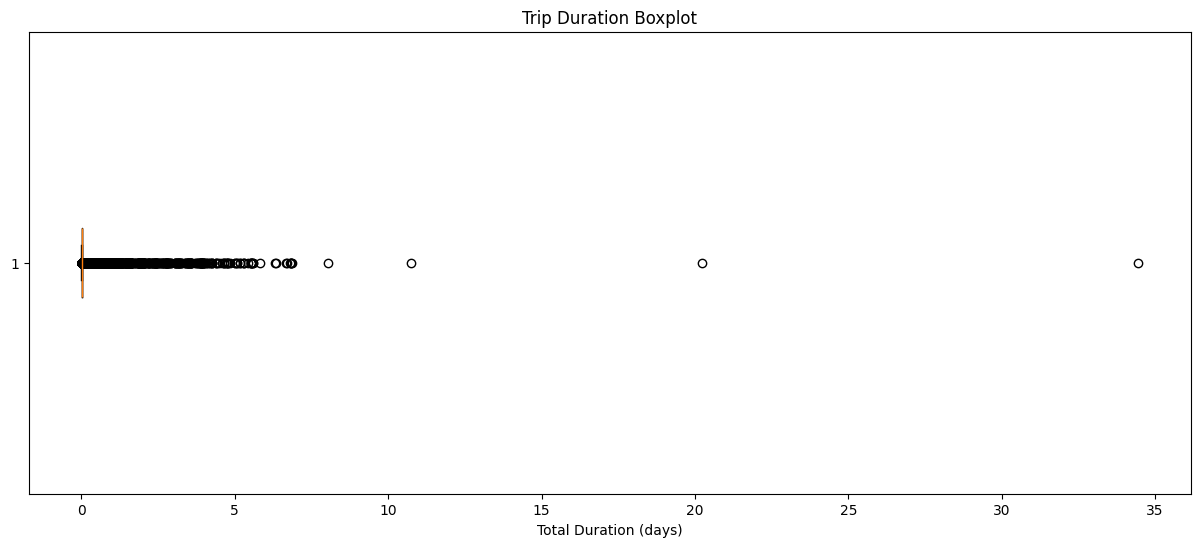

In [94]:
# Histogram of the rides duration distribution in days:
total_duration_days = df_final['Total Duration (min)'] / 3600

plt.figure(figsize=(15, 6))
plt.boxplot(total_duration_days, vert=False)
plt.xlabel('Total Duration (days)')
plt.title("Trip Duration Boxplot")
plt.show()

According to the boxplot and percentile analysis, 99% of the trips have a total duration of less than one day.  
The mean ride duration is 25.92 minutes, indicating that extremely long trips represent rare outliers.  
Therefore, for distribution analysis we will trim the data above 24 hours ride duration to reduce the impact of extreme values.

In [95]:
# Trimming dataset above 24 hours of duration :
df_final = df_final[df_final['Total Duration (min)'] <= 1440]
df_final['Total Duration (min)'].describe().round(2)

,Total Duration (min)
count,775666.00
mean,19.95
std,34.51
min,0.02
25%,8.09
50%,13.96
75%,23.16
max,1436.29


Now, after trimming of extremely high ride time, we can look though its distribution to see how our values very:

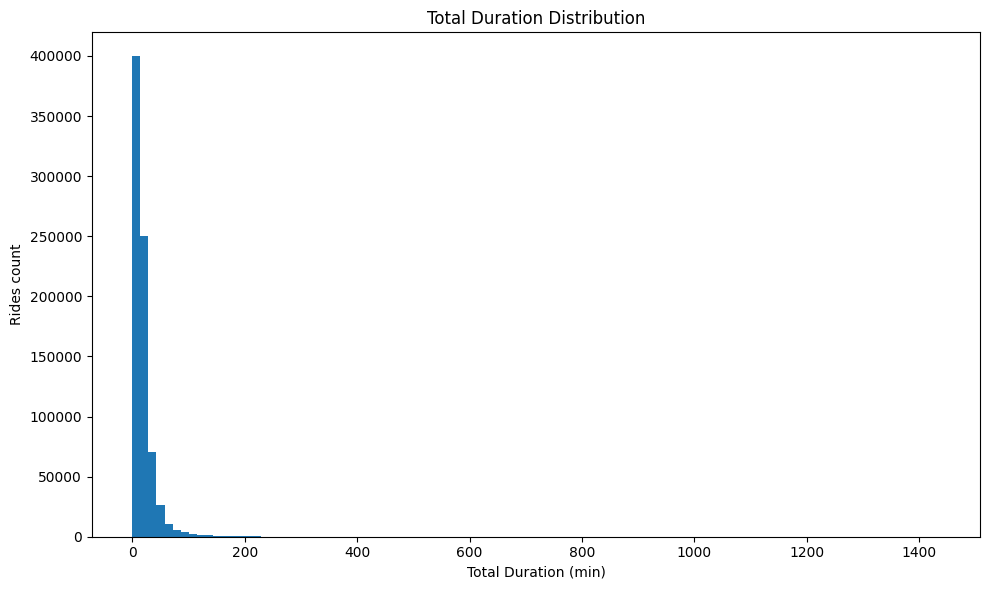

In [96]:
#creating historgam of rides destribution
plt.figure(figsize=(10, 6))
plt.hist(df_final['Total Duration (min)'], bins=100)
plt.xlabel('Total Duration (min)')
plt.ylabel('Rides count')
plt.title('Total Duration Distribution')
plt.yticks()
plt.tight_layout()
plt.show()

Our values distribution is right-tailed. Significan amout of the ride durations values are located close to minimal value. Our mean - 19.95 min, so the average ride is a short ride and the most longest ride is very rare.

## 3.2 Are there dependences between number of rides and diferent time dementions?  
For this let`s buid a line-chart to see our rides in relation to the day of the week, and hour of the day

In [97]:
# Right order for correct sequence for week days befor grouping:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_final["Weekday"] = pd.Categorical(df_final["Weekday"], categories=order, ordered=True)
df_final = df_final.sort_values("Weekday")


In [98]:
#Grouped dataframes for future visualisation
day_hour = df_final.groupby('Day hour', observed=True)['Number'].count().reset_index()
week_day = df_final.groupby('Weekday', observed=True)['Number'].count().reset_index()

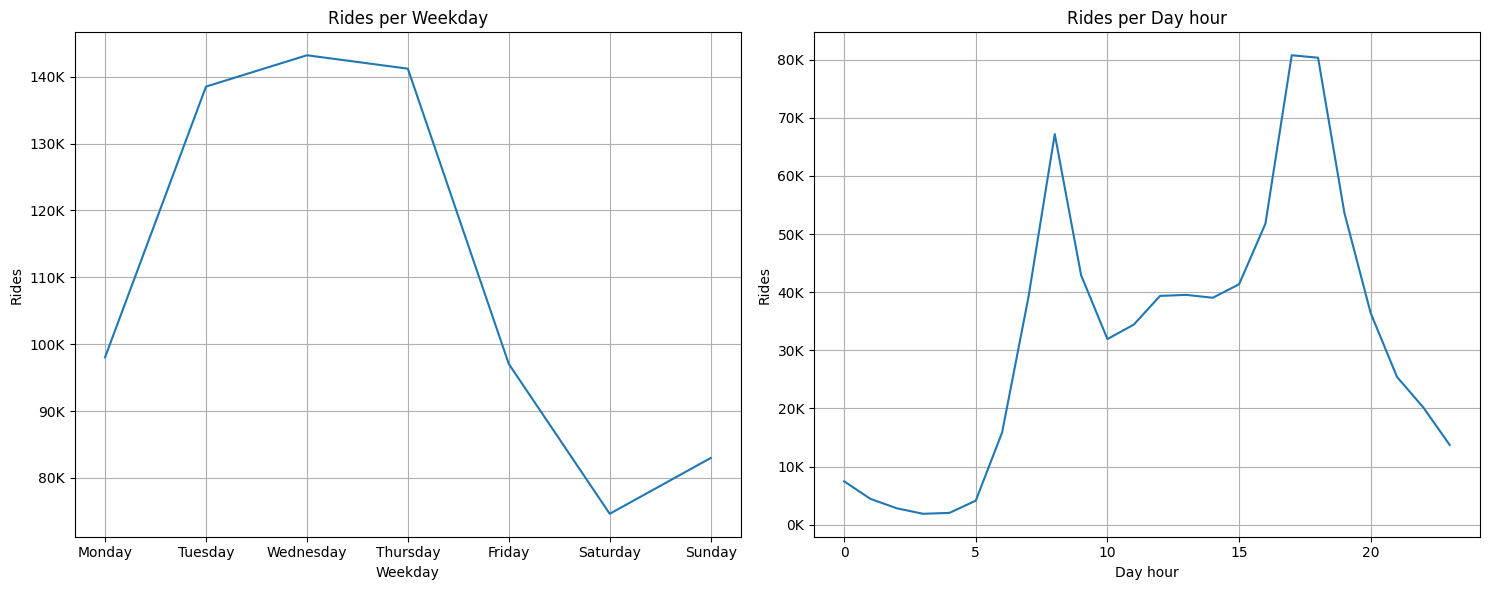

In [99]:
# Line-plots for rides per Week-day and rides per Day-hour:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.lineplot(data=week_day, x="Weekday", y="Number", ax=axes[0]) #first plot
axes[0].set_ylabel('Rides')
axes[0].set_title("Rides per Weekday")
axes[0].grid(True)

sns.lineplot(data=day_hour, x="Day hour", y="Number", ax=axes[1]) #second plot
axes[1].set_ylabel('Rides')
axes[1].set_title("Rides per Day hour")
axes[1].grid(True)

def format_k(value, pos):        # changing format of rides count display
    return f'{value/1000:.0f}K'

axes[0].yaxis.set_major_formatter(FuncFormatter(format_k))
axes[1].yaxis.set_major_formatter(FuncFormatter(format_k))


plt.tight_layout()
plt.show()



To answer the question on which spacific hour of day week is the most intensive bike traffic, we age going to visualize it using heat map:

In [100]:
#group data for creating heatmap
heat_data = df_final.groupby(['Weekday','Day hour'], observed=True)['Number'].count().unstack()

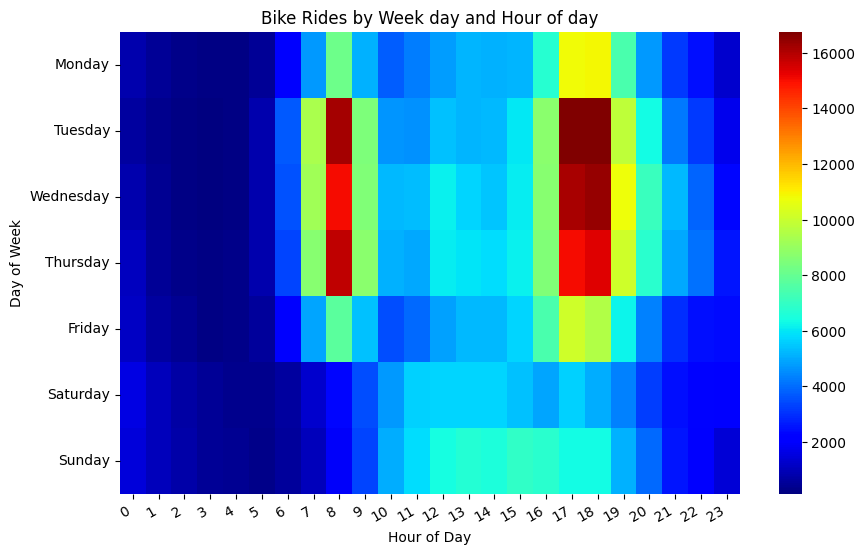

In [101]:
#Figure creation
plt.figure(figsize=(10,6))
sns.heatmap(heat_data, cmap="jet")

#Labeling
plt.title("Bike Rides by Week day and Hour of day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(rotation=30, ha='right')

plt.show()

## *Insights and Suggestions:*


1.   Weeakly demands patterns:
- Tuesday–Thursday show the highest ride volume, indicating the best income and and maximizing fleet.
- Friday drops sharply, that could be caused by increasing of remote work this day. This opens space for targeted promotions.
- Saturday is the lowest‑demand day, which signals an opportunity for spacific offers or partnerships to stimulate usage.
- Sunday recovers slightly, pointing to more flexible, non‑work travel that could be supported with individual weekend pricing.


2.   Hourly demand patterns  
-  Peaks at 8:00 and 17:00 align with morning and evening commute cycles. These hours require the highest fleet concentration and dynamic pricing strategies based on service overload.
- Very low demand between 0:00–5:00 suggests cost optimization, such as reducing active fleet or shifting maintenance to these hours.





# 3.3. Which stations and destinations are in the highest demand?

Pivot table for the most popular 10 destinations:

In [102]:

pivot_destenations = df_final.pivot_table( #creating pivot table with the columns which are provide more details
    index=[
        'Start Station Name',
        'Start Station Region',
        'End Station Name',
        'End Station Region'
    ],
    aggfunc={
        'Number': 'count',
        'Total Duration (min)': 'mean'
    }
).rename(columns={'Number': 'Trips','Total Duration (min)': 'Average Duration (min)'})

pivot_destenations = pivot_destenations.sort_values(by='Trips', ascending=False)

pivot_destenations.head(10)



,,,,Trips,Average Duration (min)
Start Station Name,Start Station Region,End Station Name,End Station Region,,
Hyde Park Corner,Hyde Park,Hyde Park Corner,Hyde Park,2966,40.897658
Podium,Queen Elizabeth Olympic Park,Podium,Queen Elizabeth Olympic Park,1812,45.024229
Triangle Car Park,Hyde Park,Triangle Car Park,Hyde Park,1390,45.770614
Black Lion Gate,Kensington Gardens,Black Lion Gate,Kensington Gardens,1343,42.823173
Albert Gate,Hyde Park,Albert Gate,Hyde Park,1227,38.349033
Park Lane,Hyde Park,Park Lane,Hyde Park,998,46.822554
Palace Gate,Kensington Gardens,Palace Gate,Kensington Gardens,571,41.228491
Queen's Gate,Kensington Gardens,Queen's Gate,Kensington Gardens,520,38.966111
Timber Lodge,Queen Elizabeth Olympic Park,Timber Lodge,Queen Elizabeth Olympic Park,487,45.870100


 Since we have top distination where start point was ended on the same station, so let`s look at total amount of these trips in relation to the total:

In [103]:

same_rides = df_final[df_final['Start Station Name'] == df_final['End Station Name']]

total_trips = len(df_final)
same_trips = len(same_rides)

percentage = same_trips / total_trips * 100
print(f'Total rides-{total_trips}, Namber of rides with the same start/end station - {same_trips}, which is  {percentage:.2f}% from the total')


Total rides-775666, Namber of rides with the same start/end station - 39763, which is  5.13% from the total


In [104]:
# Find too short rides for the within the same start/end station
same_rides_short = df_final[
    (df_final['Start Station Name'] == df_final['End Station Name']) &
    (df_final['Total Duration (min)'] < 1)
]
#creating pivot columns with agtregations by rides number
same_rides_short.pivot_table(
    index=[
        'Start Station Name',
        'Start Station Region',
        'End Station Name',
        'End Station Region'
    ],
    values='Number',
    aggfunc='count'
    ).sort_values(by='Number', ascending=False
).head(20)


,,,,Number
Start Station Name,Start Station Region,End Station Name,End Station Region,
Black Lion Gate,Kensington Gardens,Black Lion Gate,Kensington Gardens,28
Waterloo Station 1,Waterloo,Waterloo Station 1,Waterloo,27
London Fields,Hackney Central,London Fields,Hackney Central,27
Allington Street,Victoria,Allington Street,Victoria,26
Cheapside,Bank,Cheapside,Bank,25
Gas Holders,Battersea Park,Gas Holders,Battersea Park,25
Park Lane,Hyde Park,Park Lane,Hyde Park,24
Tooley Street,Bermondsey,Tooley Street,Bermondsey,22
Bethnal Green Road,Shoreditch,Bethnal Green Road,Shoreditch,22


Which are the most top 10 popular start station?

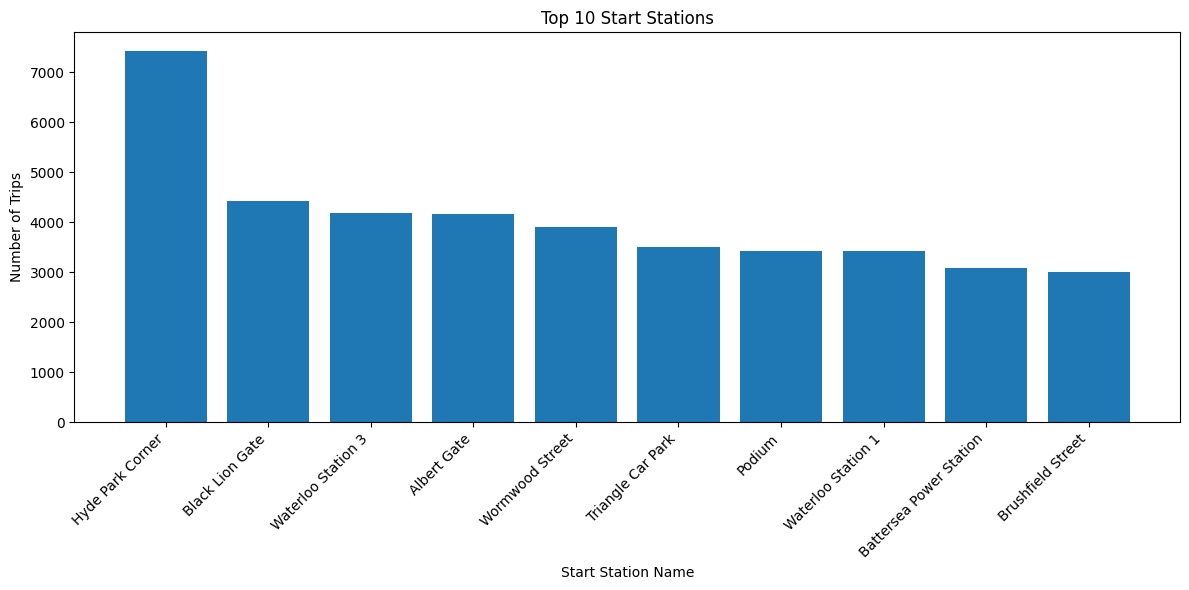

In [105]:

top_s_station = df_final.groupby('Start Station Name')['Number'].count().sort_values(ascending=False).head(10) # grouped station name by ride number

# visualisation with bar plot
plt.figure(figsize=(12, 6))
plt.bar(top_s_station.index, top_s_station.values)

plt.xlabel('Start Station Name')
plt.ylabel('Number of Trips')
plt.title('Top 10 Start Stations')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


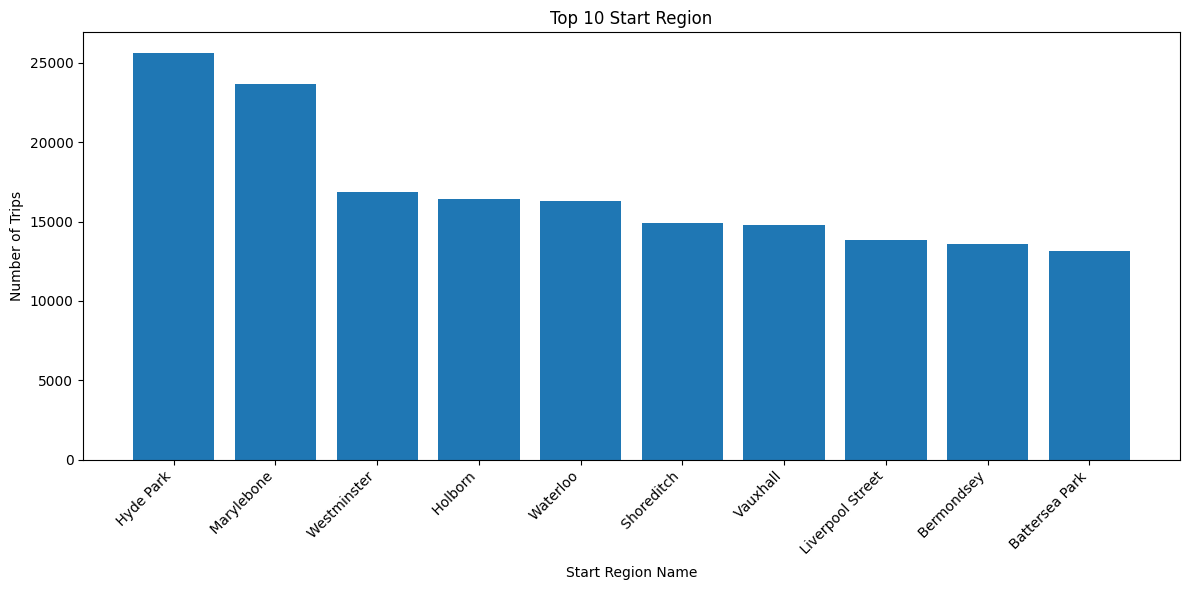

In [106]:
top_s_region = df_final.groupby('Start Station Region')['Number'].count().sort_values(ascending=False).head(10) # grouping region by count of rides with a sorting by a biggest region by rides count

# visualisation with bar plot
plt.figure(figsize=(12, 6))
plt.bar(top_s_region.index, top_s_region.values)

#labeling
plt.xlabel('Start Region Name')
plt.ylabel('Number of Trips')
plt.title('Top 10 Start Region')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Out of the top 10 start station, we can look at the average time of trip in relation to number of trips. Fot this purpuse we can build scatter plot:

In [107]:

#First, we aggregate the data by Start Station Region to calculate the total number of rides and the average trip duration.
#The data is then sorted by ride volume, and the top 10 regions are selected for further analysis
region_stats_avtime = df_final.groupby('Start Station Region').agg(
    rides=('Number', 'count'),
    average_duration=('Total Duration (min)', 'mean')
).reset_index().sort_values(by="rides", ascending=False).head(10)



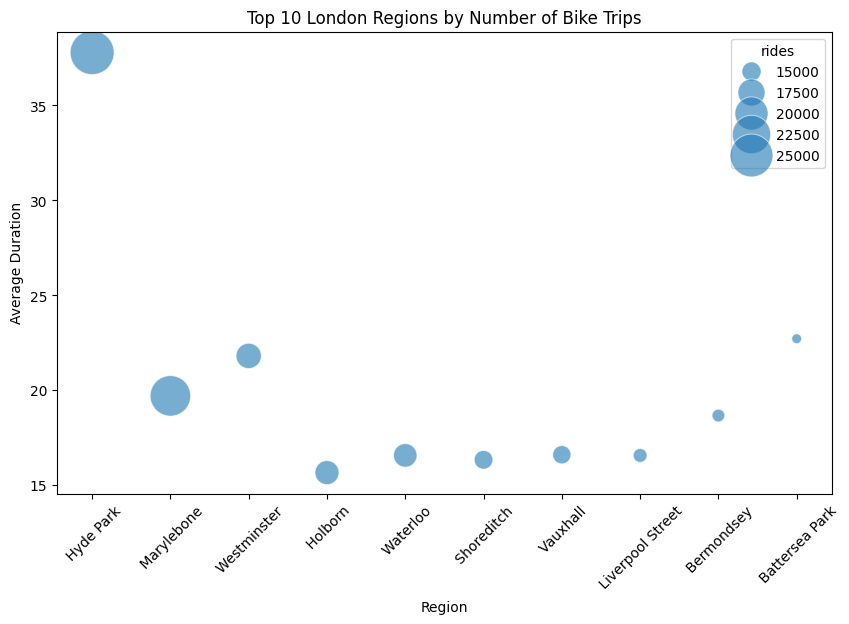

In [108]:
#creating figure
plt.figure(figsize=(10,6))

#parameters of scatterplot
sns.scatterplot(
    data=region_stats_avtime,
    x='Start Station Region',
    y='average_duration',
    size='rides',
    sizes=(50,1000),
    alpha=0.6
)
#labeling
plt.xticks(rotation=45)
plt.title("Top 10 London Regions by Number of Bike Trips")
plt.xlabel("Region")
plt.ylabel("Average Duration")
plt.show()

## **Insights and Suggestions:**

-  Our top destinations are:   
 *Hyde Park Corner*	*with	2966 rides per month and average ride time - 	40.89 minutes  
*Podium	Queen Elizabeth Olympic Park*	with 	1812 tital rides and average trip time -	45.02 min   
*Triangle Car Park*	1390 rides and average- 45.77min   
The highest ride volumes are concentrated in large central parks, suggesting that these areas are popular for leisure trips. This highlights key locations where increasing bike availability or expanding station capacity could help optimize service and meet demand.  
-  We can see a few suspicious rides based on ride duratiuon < 1 min, where *Black Lion Gate, Waterloo Station 1 and  London Fields* and have more than 26 rides less then 1 minute. It can help us to identify technical issue with the bike station point or an application bugs.  
- The highest ride demand is concentrated in *Hyde Park, Marylebone, and Westminster*.
These high-traffic regions should be prioritized for operational support and maintenance to minimize downtime and ensure service reliability.
- *Hyde Park* shows the longest average trip duration, suggesting that rides starting there are more likely to be leisure trips rather than commuting.
In contrast, regions such as *Holborn and Shoreditch* have shorter average ride durations, which may indicate commuter usage patterns.






# **3.4** **Bike Model Usage Analysis and potential bikes for service or app bugs**

Let’s analyze bike types and identify which models are most frequently used by customers. Fot this purpose we`ll create piechart and Seaborn library

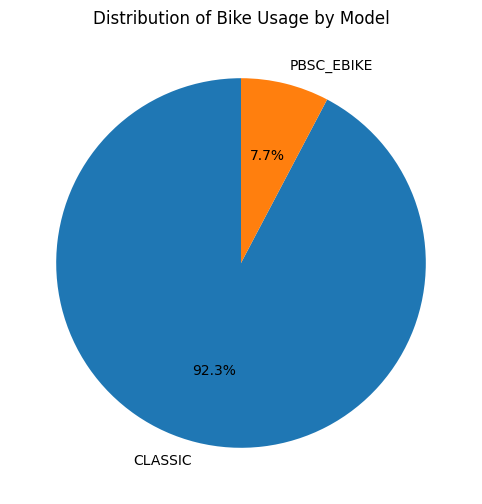

In [109]:
bike_usage = df_final.groupby('Bike model', observed=True)['Number'].count().sort_values(ascending=False) # grouping our bikes on the total rides

#plotting data on chart and adding parametrs:
plt.figure(figsize=(10,6))
plt.pie(
    bike_usage,
    labels=bike_usage.index,
    autopct='%1.1f%%',
    startangle=90
)
#chart title
plt.title("Distribution of Bike Usage by Model")

plt.show()


Is there some patterns for bike model usage by weekday and hour of the day?

In [110]:
#grouping data based on bike type to hour and weekay:
hour_bike_type = (
    df_final
    .groupby(['Day hour', 'Bike model'], observed=True)['Number']
    .count()
    .reset_index()
)

weekday_bike_type = (
    df_final
    .groupby(['Weekday', 'Bike model'], observed=True)['Number']
    .count()
    .reset_index()
)

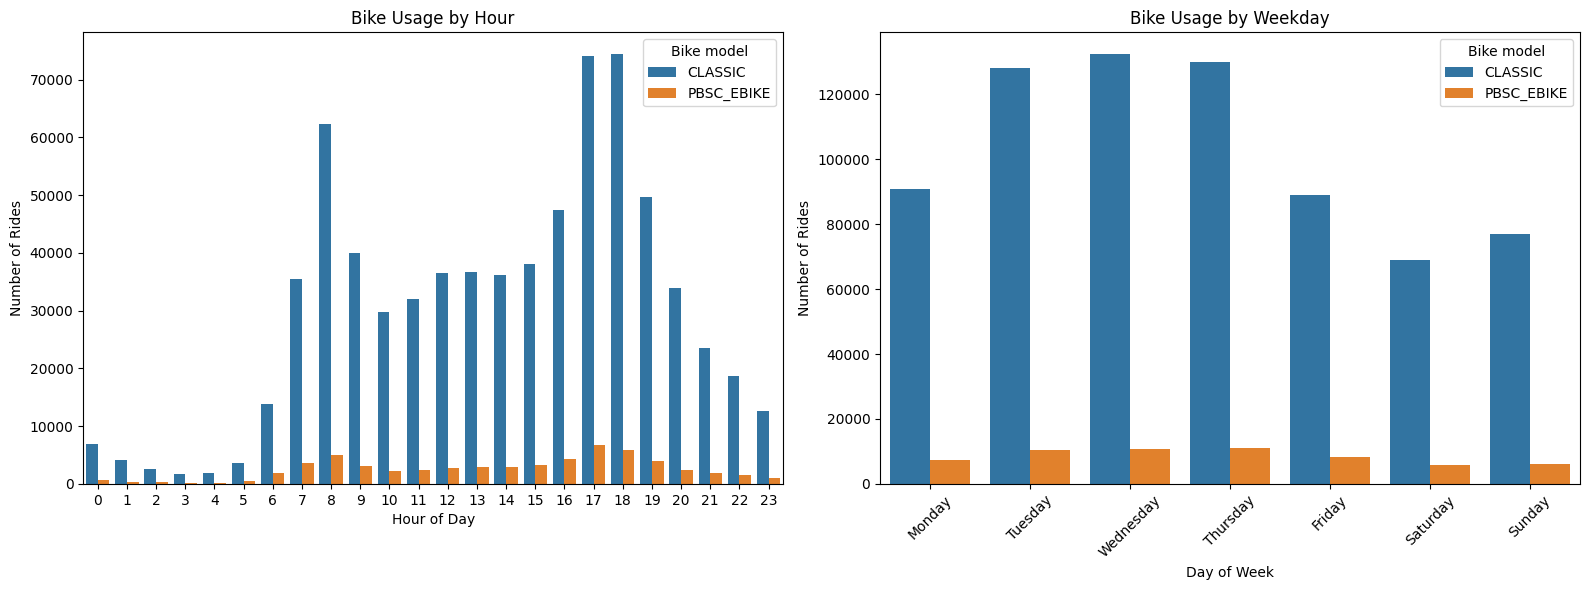

In [111]:
# Створюємо 2 графіки
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Graph 1 paramerts for hour in relation to count of rides per bike type
sns.barplot(
    data=hour_bike_type,
    x='Day hour',
    y='Number',
    hue='Bike model',
    ax=axes[0]
)
#labeling
axes[0].set_title("Bike Usage by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Rides")

# Graph 2 paramerts for weekday in relation to count of rides per bike type

sns.barplot(
    data=weekday_bike_type,
    x='Weekday',
    y='Number',
    hue='Bike model',
    ax=axes[1]
)
#labeling
axes[1].set_title("Bike Usage by Weekday")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Rides")
#rotation of weekdays
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The relationship between bike type, weekday, and hour of the day shows a consistent pattern, with no noticeable anomalies or irregularities across time periods.Therefore, we proceed to analyze the distribution of rides across bike types for the top 10 start stations.

In [112]:
# Sorted list of the top 10 start station
top_stations = (
    df_final['Start Station Name']
    .value_counts()
    .head(10)
    .index
)

data = df_final[df_final['Start Station Name'].isin(top_stations)] #new dataframe with only top 10 station

#pivot table for visualisation with grouping start station and bike model in relation to rides number
pivot = (
    data
    .groupby(['Start Station Name', 'Bike model'], observed=True)['Number']
    .count()
    .unstack()
    .fillna(0)
)

In [113]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) *100 #normalizing and transform in %

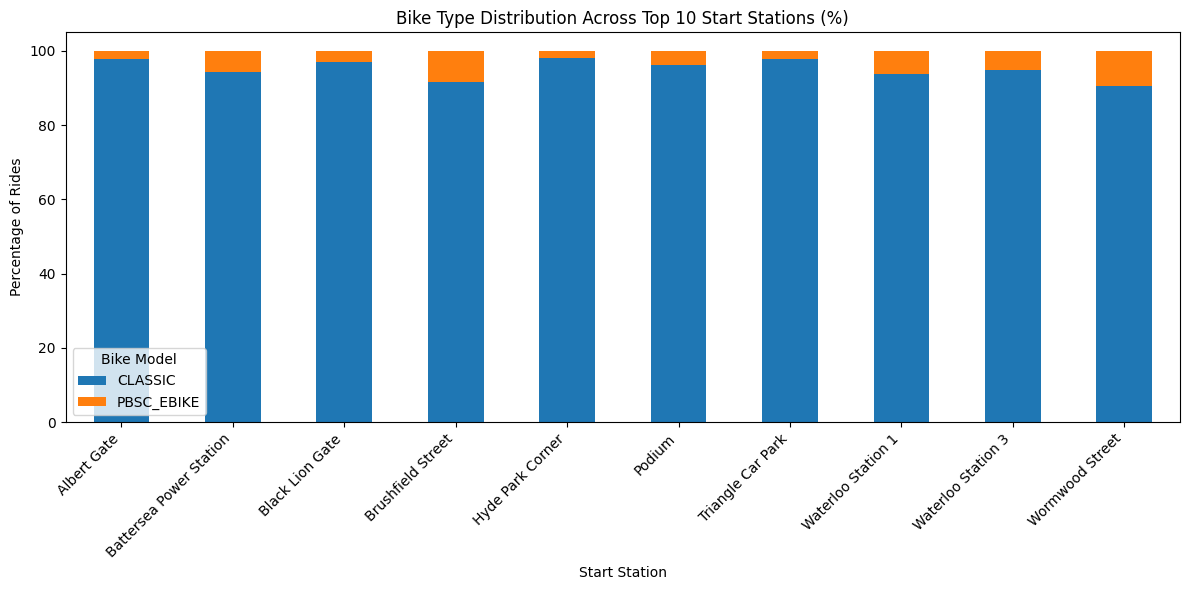

In [114]:
pivot_pct.plot(    #set bar plot parametrs
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Bike Type Distribution Across Top 10 Start Stations (%)") # labeling
plt.xlabel("Start Station")
plt.ylabel("Percentage of Rides")

plt.xticks(rotation=45, ha='right')
plt.legend(title='Bike Model')

plt.tight_layout()
plt.show()

We can search for the bikes number with the ride lentgh less than 1 min to identify the ones that migh need technical service:

In [115]:
# filtered dataframe for rides with a small duration
df_short = df_final[df_final["Total Duration (min)"] < 1]

# grouping and sorting
bike_short_counts = (
    df_short.groupby("Bike number")
            .size()
            .reset_index(name="Trip count (<1 min)")
            .sort_values("Trip count (<1 min)", ascending=False)
)

bike_short_counts.head()


,Bike number,Trip count (<1 min)
354,21205,15
492,22653,11
2877,58573,10
1392,51592,8
3045,59379,8


Top individual bikes with the most utilisation rate:

In [116]:
# creating pivot with a grouping by bike number and aggregated for total rides and its duration:
pivot_bikes = (
    df_final
    .groupby("Bike number")
    .agg(
        Total_Trips=("Number", "count"),
        Total_Duration_Min=("Total Duration (min)", "sum")
    )
    .sort_values("Total_Duration_Min", ascending=False)
    .round(2)
)
#adding column for hours
pivot_bikes["Total_Duration_Hours"] = (pivot_bikes["Total_Duration_Min"] / 60).round(2)

pivot_bikes.head(10)



,Total_Trips,Total_Duration_Min,Total_Duration_Hours
Bike number,,,
58325,188,4459.70,74.33
58819,208,4372.20,72.87
57323,94,4363.99,72.73
54063,119,4337.15,72.29
41826,82,4276.27,71.27
55930,87,4020.55,67.01
11496,16,3979.71,66.33
59510,168,3958.28,65.97
59906,152,3899.71,65.00


## **Insights and Suggestions:**  
- The system operates consistently, with no anomalies in bike model usage across hours or days of the week.
- CLASSIC bikes are the primary model, accounting for the majority of all rides.
- E‑bikes show stable usage patterns, though their share varies depending on the station.
- The top stations exhibit different demand profiles, which creates opportunities to optimize fleet distribution.
- Short rides under one minute are an important indicator of potential technical issues and should be monitored.
- The most heavily used bikes are critical for operational efficiency and should receive prioritized maintenance.
